# Seoul Bike Demand Prediction — LightGBM

Run the cells sequentially. The notebook performs preprocessing, hyperparameter selection with 5-fold cross-validation, evaluation, training/validation MSE plotting, final training, and submission generation.

In [1]:
# 1. Imports and configuration
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

BASE_DIR = os.getcwd()
TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
TEST_PATH = os.path.join(BASE_DIR, "test.csv")
SUB_PATH = os.path.join(BASE_DIR, "submission.csv")
PLOT_PATH = os.path.join(BASE_DIR, "training_vs_validation_mse.png")

print("Working directory:", BASE_DIR)


Working directory: /Users/kaushiksathyanathsingh/Documents/ML project/Regression


In [2]:
# 2. Preprocessing function
def preprocess_data(df, is_train=True):
    df_feat = df.copy()

    col_rename = {
        'Temperature(°C)': 'Temperature',
        'Humidity(%)': 'Humidity',
        'Wind speed (m/s)': 'Wind speed',
        'Visibility (10m)': 'Visibility',
        'Dew point temperature(°C)': 'Dew point temperature',
        'Solar Radiation (MJ/m2)': 'Solar Radiation',
        'Rainfall(mm)': 'Rainfall',
        'Snowfall (cm)': 'Snowfall'
    }
    df_feat = df_feat.rename(columns=col_rename)

    # Date/time features
    df_feat['Date_dt'] = pd.to_datetime(df_feat['Date'], format='%d/%m/%Y')
    df_feat['Year'] = df_feat['Date_dt'].dt.year
    df_feat['Month'] = df_feat['Date_dt'].dt.month
    df_feat['Day'] = df_feat['Date_dt'].dt.day
    df_feat['DayOfWeek'] = df_feat['Date_dt'].dt.dayofweek
    df_feat['Is_Weekend'] = (df_feat['DayOfWeek'] >= 5).astype(int)

    # Season correction
    month_to_season = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    }
    df_feat['Seasons'] = df_feat['Month'].map(month_to_season)

    # Cyclical encodings
    df_feat['Hour_sin'] = np.sin(2 * np.pi * df_feat['Hour'] / 24.0)
    df_feat['Hour_cos'] = np.cos(2 * np.pi * df_feat['Hour'] / 24.0)
    df_feat['Month_sin'] = np.sin(2 * np.pi * df_feat['Month'] / 12.0)
    df_feat['Month_cos'] = np.cos(2 * np.pi * df_feat['Month'] / 12.0)
    df_feat['DayOfWeek_sin'] = np.sin(2 * np.pi * df_feat['DayOfWeek'] / 7.0)
    df_feat['DayOfWeek_cos'] = np.cos(2 * np.pi * df_feat['DayOfWeek'] / 7.0)

    # Weather imputation and interactions
    num_cols = ['Temperature', 'Wind speed', 'Solar Radiation', 'Rainfall']
    for col in num_cols:
        if col in df_feat.columns:
            df_feat[col] = (
                df_feat.groupby(['Month', 'Hour'])[col]
                .transform(lambda x: x.fillna(x.median()))
            )
            df_feat[col] = df_feat[col].fillna(df_feat[col].median())

    df_feat['Is_Raining'] = (df_feat['Rainfall'] > 0).astype(int)
    df_feat['Is_Snowing'] = (df_feat['Snowfall'] > 0).astype(int)
    df_feat['Temp_Humidity_Interaction'] = (
        df_feat['Temperature'] * (df_feat['Humidity'] / 100.0)
    )
    df_feat['Temp_Solar_Interaction'] = (
        df_feat['Temperature'] * df_feat['Solar Radiation']
    )

    # Metadata
    drop_cols = ['Date', 'Date_dt', 'Kaggle_ID', 'Record_id']
    drop_cols = [c for c in drop_cols if c in df_feat.columns]
    df_feat = df_feat.drop(columns=drop_cols)

    # One-hot encoding
    return pd.get_dummies(
        df_feat,
        columns=['Seasons', 'Holiday', 'Functioning Day'],
        drop_first=True
    )


In [3]:
# 3. Load data
if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    raise FileNotFoundError(
        "train.csv and test.csv must be in the notebook working directory."
    )

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print("\nTrain columns:")
print(train_df.columns.tolist())


Train shape: (7093, 16)
Test shape:  (2628, 15)

Train columns:
['Kaggle_ID', 'Date', 'Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning Day', 'Record_id', 'Rented Bike Count']


In [4]:
# 4. Preprocess data
train_proc = preprocess_data(train_df, is_train=True)
test_proc = preprocess_data(test_df, is_train=False)

X_train = train_proc.drop(columns=['Rented Bike Count'])
y_train = train_proc['Rented Bike Count']
X_test = test_proc

# Make train/test feature columns identical
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("Feature matrix:", X_train.shape)


Feature matrix: (7093, 29)


In [7]:
# 5. Set up 5-fold cross-validation and randomized hyperparameter search

from sklearn.model_selection import KFold, RandomizedSearchCV

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter search space
param_grid = {
    'n_estimators': [300, 500, 700, 1000],
    'learning_rate': [0.02, 0.03, 0.05],
    'num_leaves': [25, 40, 60],
    'min_child_samples': [20, 30, 50],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

# LightGBM uses the CPU on Apple Silicon.
# n_jobs=-1 uses all available CPU cores.
base_model = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# RandomizedSearchCV avoids testing every possible combination.
# 40 combinations × 5 folds = 200 model fits.
search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='neg_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    random_state=42,
    refit=True,
    return_train_score=True,
    verbose=1
)

total_combinations = np.prod([
    len(v) for v in param_grid.values()
])

print("Total possible parameter combinations:", total_combinations)
print("Random combinations tested:", 40)
print("Total CV model fits:", 40 * 5)

Total possible parameter combinations: 432
Random combinations tested: 40
Total CV model fits: 200


In [8]:
# 6. Run hyperparameter search

search.fit(X_train, y_train)

best_params = search.best_params_
best_cv_mse = -search.best_score_

print("\nBEST PARAMETERS")

for key, value in best_params.items():
    print(f"{key:22s}: {value}")

print(f"\nBest mean CV MSE : {best_cv_mse:.4f}")
print(f"Best mean CV RMSE: {np.sqrt(best_cv_mse):.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

BEST PARAMETERS
subsample             : 0.8
num_leaves            : 60
n_estimators          : 1000
min_child_samples     : 20
learning_rate         : 0.05
colsample_bytree      : 0.9

Best mean CV MSE : 65979.3153
Best mean CV RMSE: 256.8644


In [9]:
# 7. Inspect the best search result
cv_table = pd.DataFrame(search.cv_results_)

cols = [
    'rank_test_score',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'params'
]

best_results = cv_table[cols].copy()
best_results['mean_train_mse'] = -best_results['mean_train_score']
best_results['mean_validation_mse'] = -best_results['mean_test_score']
best_results['validation_rmse'] = np.sqrt(best_results['mean_validation_mse'])

best_results = best_results.sort_values('rank_test_score')

best_results[
    ['rank_test_score', 'mean_train_mse',
     'mean_validation_mse', 'validation_rmse',
     'std_test_score', 'params']
].head(10)


,rank_test_score,mean_train_mse,mean_validation_mse,validation_rmse,std_test_score,params
16,1,921.569623,65979.315314,256.864391,13505.981540,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
33,2,6404.443546,66257.070401,257.404488,13138.137137,"{'subsample': 0.9, 'num_leaves': 40, 'n_estima..."
7,3,4038.308625,66326.658972,257.539626,12350.025693,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
9,4,8736.536277,66578.597394,258.028288,12636.425734,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
32,5,5290.102797,66592.631866,258.055482,13727.892534,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
35,6,16530.902436,66642.211189,258.151528,13041.421478,"{'subsample': 0.9, 'num_leaves': 60, 'n_estima..."
36,7,4828.036271,67044.088609,258.928733,12822.285348,"{'subsample': 0.8, 'num_leaves': 40, 'n_estima..."
10,8,8177.037981,67212.866153,259.254443,13238.768641,"{'subsample': 0.9, 'num_leaves': 40, 'n_estima..."
26,9,10215.958224,67378.315847,259.573334,13057.201763,"{'subsample': 0.9, 'num_leaves': 25, 'n_estima..."
15,10,11450.219785,67386.506081,259.589110,12975.982153,"{'subsample': 0.9, 'num_leaves': 60, 'n_estima..."


In [ ]:
# 8. Detailed 5-fold evaluation of the selected model
def get_model(params=None):
    base_params = {
        'n_estimators': 700,
        'learning_rate': 0.03,
        'num_leaves': 40,
        'min_child_samples': 30,
        'subsample': 0.85,
        'colsample_bytree': 0.85,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }
    if params:
        base_params.update(params)
    return LGBMRegressor(**base_params)

best_model = get_model(best_params)

cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=kf,
    scoring={
        'mse': 'neg_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    return_train_score=True,
    n_jobs=-1
)

train_mse = -cv_results['train_mse']
val_mse = -cv_results['test_mse']
train_mae = -cv_results['train_mae']
val_mae = -cv_results['test_mae']
train_r2 = cv_results['train_r2']
val_r2 = cv_results['test_r2']

fold_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Train MSE': train_mse,
    'Validation MSE': val_mse,
    'Validation RMSE': np.sqrt(val_mse),
    'Train MAE': train_mae,
    'Validation MAE': val_mae,
    'Train R2': train_r2,
    'Validation R2': val_r2
})

fold_results


,Fold,Train MSE,Validation MSE,Validation RMSE,Train MAE,Validation MAE,Train R2,Validation R2
0,1,941.999213,88515.358212,297.515308,18.978153,136.971949,0.997828,0.804551
1,2,777.073672,66340.006681,257.565539,18.175973,127.935490,0.998227,0.847423
2,3,941.244435,51827.552884,227.656656,19.198579,117.234378,0.997858,0.879554
3,4,1001.820147,52508.897956,229.148201,20.183974,115.211842,0.997735,0.874373
4,5,945.710647,70704.760838,265.903668,18.821264,127.411242,0.997822,0.843129


In [ ]:
# 9. Print CV summary
print("5-FOLD CROSS-VALIDATION SUMMARY")
print(f"Mean Train MSE       : {np.mean(train_mse):.2f}")
print(f"Mean Validation MSE  : {np.mean(val_mse):.2f}")
print(f"Mean Train RMSE      : {np.sqrt(np.mean(train_mse)):.2f}")
print(f"Mean Validation RMSE : {np.sqrt(np.mean(val_mse)):.2f}")
print(f"Mean Train MAE       : {np.mean(train_mae):.2f}")
print(f"Mean Validation MAE  : {np.mean(val_mae):.2f}")
print(f"Mean Train R²        : {np.mean(train_r2):.4f}")
print(f"Mean Validation R²   : {np.mean(val_r2):.4f}")
print(f"Validation MSE SD    : {np.std(val_mse):.2f}")

generalization_gap = np.mean(val_mse) - np.mean(train_mse)
print(f"\nValidation - Train MSE gap: {generalization_gap:.2f}")


5-FOLD CROSS-VALIDATION SUMMARY
Mean Train MSE       : 921.57
Mean Validation MSE  : 65979.32
Mean Train RMSE      : 30.36
Mean Validation RMSE : 256.86
Mean Train MAE       : 19.07
Mean Validation MAE  : 124.95
Mean Train R²        : 0.9979
Mean Validation R²   : 0.8498
Validation MSE SD    : 13505.98

Validation - Train MSE gap: 65057.75


In [12]:
# 10. Training vs validation MSE as number of trees increases
best_n_estimators = best_params['n_estimators']

curve_estimators = sorted(set([
    100, 200, 300, 400, 500,
    600, 700, 800, 900, 1000,
    best_n_estimators
]))

curve_train_mse = []
curve_val_mse = []

curve_params = best_params.copy()

for n_estimators in curve_estimators:
    curve_params['n_estimators'] = n_estimators
    model = get_model(curve_params)

    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_mean_squared_error',
        return_train_score=True,
        n_jobs=-1
    )

    curve_train_mse.append(-np.mean(result['train_score']))
    curve_val_mse.append(-np.mean(result['test_score']))

curve_df = pd.DataFrame({
    'n_estimators': curve_estimators,
    'Training MSE': curve_train_mse,
    'Validation MSE': curve_val_mse
})

curve_df


,n_estimators,Training MSE,Validation MSE
0,100,28996.375062,70653.034625
1,200,14453.766641,67022.618720
2,300,8689.179133,66401.980671
3,400,5701.999537,66026.601746
4,500,3935.439518,65981.546497
5,600,2849.771065,65957.094883
6,700,2082.916035,65909.304370
7,800,1570.796221,65952.772818
8,900,1186.952215,65967.285361
9,1000,921.569623,65979.315314


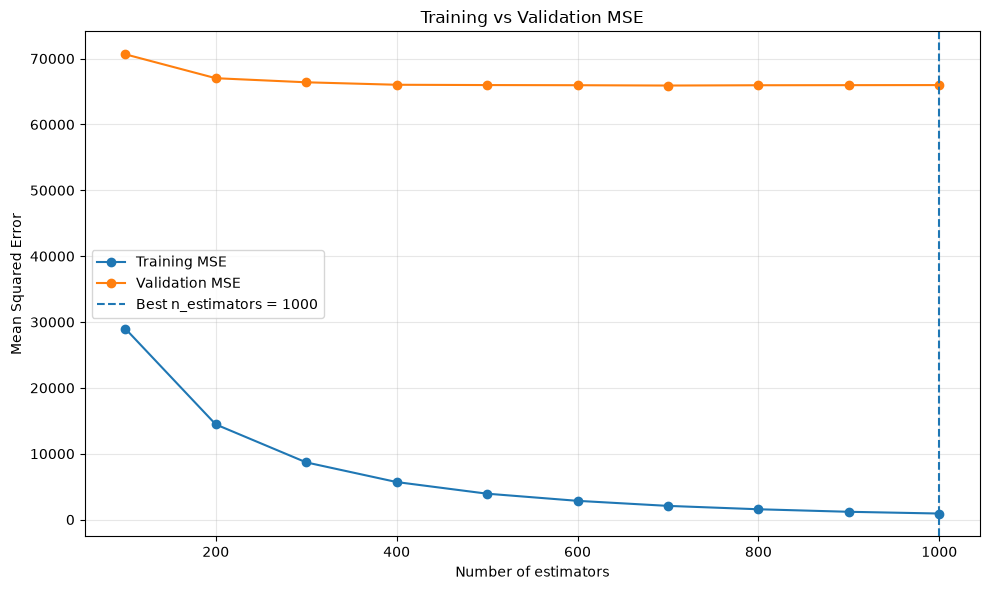

In [13]:
# 11. Plot training and validation MSE
plt.figure(figsize=(10, 6))

plt.plot(
    curve_estimators,
    curve_train_mse,
    marker='o',
    label='Training MSE'
)

plt.plot(
    curve_estimators,
    curve_val_mse,
    marker='o',
    label='Validation MSE'
)

plt.axvline(
    best_n_estimators,
    linestyle='--',
    label=f'Best n_estimators = {best_n_estimators}'
)

plt.xlabel('Number of estimators')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Validation MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# plt.savefig(PLOT_PATH, dpi=150)
plt.show()

# print("Saved:", PLOT_PATH)


In [14]:
# 12. Train final model on all training data
final_model = get_model(best_params)
final_model.fit(X_train, y_train)

print("Final model trained.")


Final model trained.


In [15]:
# 13. Test error, if test labels are available
if 'Rented Bike Count' in test_df.columns:
    test_preds = np.clip(
        final_model.predict(X_test),
        0,
        None
    )

    y_test = test_df['Rented Bike Count'].values

    test_mse = mean_squared_error(y_test, test_preds)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, test_preds)
    test_r2 = r2_score(y_test, test_preds)

    print("TRUE TEST ERROR")
    print(f"Test MSE  : {test_mse:.2f}")
    print(f"Test RMSE : {test_rmse:.2f}")
    print(f"Test MAE  : {test_mae:.2f}")
    print(f"Test R²   : {test_r2:.4f}")
else:
    print("test.csv has no 'Rented Bike Count'.")
    print("A true test MSE cannot be calculated.")
    print(f"5-fold CV validation MSE: {np.mean(val_mse):.2f}")
    print(f"5-fold CV validation RMSE: {np.sqrt(np.mean(val_mse)):.2f}")


test.csv has no 'Rented Bike Count'.
A true test MSE cannot be calculated.
5-fold CV validation MSE: 65979.32
5-fold CV validation RMSE: 256.86


In [16]:
# 14. Generate submission
test_preds = np.clip(
    final_model.predict(X_test),
    0,
    None
)

test_preds_rounded = np.round(test_preds).astype(int)

if 'Kaggle_ID' in test_df.columns:
    sub_df = pd.DataFrame({
        'Kaggle_ID': test_df['Kaggle_ID'],
        'Rented Bike Count': test_preds_rounded
    })
else:
    sub_df = pd.DataFrame({
        'Rented Bike Count': test_preds_rounded
    })

sub_df.to_csv(SUB_PATH, index=False)

print("Saved submission:", SUB_PATH)
print(sub_df.head())


Saved submission: /Users/kaushiksathyanathsingh/Documents/ML project/Regression/submission.csv
   Kaggle_ID  Rented Bike Count
0          0                478
1          1                803
2          2                392
3          3                400
4          4                276


In [ ]:
neg_mean_squared_log_error